In [1]:
#Importing all the necessary libraries
import os
import sys
import pickle
import time

import jax
import jax.numpy as jnp
import numpy as np
from scipy.io import loadmat

import flax
from flax import linen as nn

import optax
import matplotlib.pyplot as plt
import matplotlib
from typing import Callable, List
import scipy
from tqdm import tqdm

from models_fno import FNO2d
from utils import save_model_params, load_model_params
from utils import dataloader

In [2]:
base_path = "/home/dnayak2/data_sgoswam4/Dibya/Datasets/1D_KS/"
outputs = (scipy.io.loadmat(os.path.join(base_path, "KS_simple.mat"))["u_out"])[:3000]

Ns, Nt, Nx = outputs.shape
print(f"Ns: {Ns}, Nt: {Nt}, Nx: {Nx}")

Ns: 3000, Nt: 300, Nx: 128


In [3]:
inputs = outputs[:,0,:]
inputs.shape, outputs.shape

((3000, 128), (3000, 300, 128))

In [4]:
# Create coordinate grids
xspan = jnp.linspace(0, 1, Nx)  # spatial domain
tspan = jnp.linspace(0, 1, Nt)  # temporal domain

print(xspan.shape, tspan.shape)

# Meshgrid to create 2D coordinate arrays
[T, X] = jnp.meshgrid(tspan, xspan, indexing='ij')

#T and X have (Nt, Nx)
T_tiled = jnp.tile(T[None,:,:], (Ns,1,1))
X_tiled = jnp.tile(X[None,:,:], (Ns,1,1))

# tile inputs
inputs_tiled = jnp.tile(inputs[:,None,:], (1, Nt, 1))

#Stack all
inputs_to_FNO = jnp.stack([inputs_tiled, T_tiled, X_tiled], axis=-1)
output_FNO = outputs[:,:,:,None]
print(inputs_to_FNO.shape, output_FNO.shape)

2025-11-14 17:58:20.662492: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.5.82). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


(128,) (300,)
(3000, 300, 128, 3) (3000, 300, 128, 1)


In [5]:
#Free up some memory
del inputs_tiled, T_tiled, X_tiled

In [6]:
#Create the FNO-2D model object
modes1 = 64
modes2 = 64

#Create the FNO-2D model object
fno = FNO2d(in_channels = 3,
            out_channels = 1,
            modes1 = modes1,
            modes2 = modes2,
            width = 64,
            n_blocks = 6,
            activation = nn.activation.gelu,  
)
model_fn = jax.jit(fno.apply)

In [7]:
# Load the best model parameters
result_dir = "./FNO_full_rollout"
filename = f"best_model_params_FNO_{modes1}modes_73957.pkl"

best_params = load_model_params(result_dir, filename = filename)

In [8]:
#-----Peform batched inference-------#

u0 = outputs[:, 0, :, None]     #(Ns, Nx, Ny, Nv=1)

# Shared coordinate grid (Nt, Nx, 2)
T, X = jnp.meshgrid(tspan, xspan, indexing="ij")
coords = jnp.stack([T, X], axis=-1)   # (Nt, Nx, 2)

def fno_forward(params, u0, coords):
    """
    u0: (B, Nx, 1)    initial condition
    coords: (Nt, Nx, 2)  shared (t,x) grid
    returns: (B, Nt, Nx, 1)  predicted solution
    """
    B, Nx, _ = u0.shape
    Nt = coords.shape[0]

    # Broadcast u0 along time
    u0_b = jnp.broadcast_to(u0[:, None, ...], (B, Nt, Nx, 1))  # (B, Nt, Nx, 1)

    # Add batch axis to coords
    coords_b = jnp.broadcast_to(coords[None, ...], (B, Nt, Nx, 2))  # (B, Nt, Nx, 2)

    # Concatenate along channel axis
    inputs = jnp.concatenate([u0_b, coords_b], axis=-1)  # (B, Nt, Nx, 3)

    return model_fn(params, inputs)

start_time = time.time()

print("Starting batched FR inference")
BATCH = 8
preds = []
for i in range(0, Ns, BATCH):
    u0_batch = u0[i:i+BATCH]   # (B, Nx, 1)
    pred = fno_forward(best_params, u0_batch, coords)
    preds.append(pred)
pred_FNO = jnp.concatenate(preds, axis=0)  # (Ns, Nt, Nx, 1)
print(f"FNO output prediction shape: {pred_FNO.shape}")
print("FR inference complete..")

end_time = time.time()

print(f"Inference time: {end_time-start_time} secs")
#-----------------------------------------------#

Starting batched FR inference
FNO output prediction shape: (3000, 300, 128, 1)
FR inference complete..
Inference time: 7.169643878936768 secs


In [52]:
pred_FNO.shape, output_FNO.shape

((3000, 300, 128, 1), (3000, 300, 128, 1))

In [53]:
overall_rel_L2_err = np.linalg.norm(pred_FNO - output_FNO)/np.linalg.norm(output_FNO)
overall_rel_L2_err

np.float64(0.8812768856512534)

In [54]:
idx=70

In [55]:
pred_FNO_ = pred_FNO.squeeze(axis=-1)
output_FNO_ = output_FNO.squeeze(axis=-1)

pred_FNO_.shape, output_FNO_.shape

((3000, 300, 128), (3000, 300, 128))

In [56]:
idx = 140

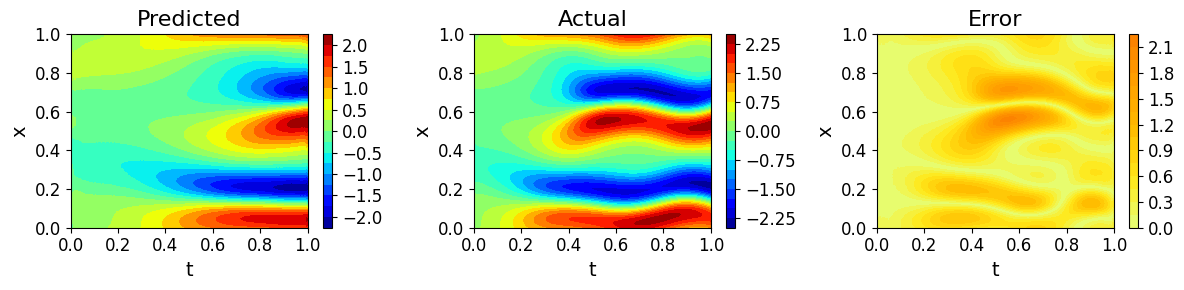

In [57]:
error = np.abs(pred_FNO_ - output_FNO_)

plt.figure(figsize = (12,3))
    
plt.subplot(1,3,1)
contour1 = plt.contourf(tspan, xspan, pred_FNO_[idx, :, :].T, levels = 20, cmap = 'jet')
cbar1 = plt.colorbar()
cbar1.ax.tick_params(labelsize = 12)
plt.xlabel("t", fontsize = 14)
plt.ylabel("x", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Predicted", fontsize = 16)

plt.subplot(1,3,2)
contour2 = plt.contourf(tspan, xspan, output_FNO_[idx, :, :].T, levels = 20, cmap = 'jet')
cbar2 = plt.colorbar()
cbar2.ax.tick_params(labelsize = 12)
plt.xlabel("t", fontsize = 14)
plt.ylabel("x", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Actual", fontsize = 16)


plt.subplot(1,3,3)
contour3 = plt.contourf(tspan, xspan, error[idx, :, :].T, levels = 20, cmap = 'Wistia')
cbar3 = plt.colorbar()
cbar3.ax.tick_params(labelsize = 12)
plt.xlabel("t", fontsize = 14)
plt.ylabel("x", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Error", fontsize = 16)

plt.tight_layout()
# plt.savefig(filepath + f"/Contour_plots_sidx{i}.jpeg", dpi = 800)
plt.show()

In [58]:
auto_reg_error = []

for i in range(Nt):
    err = np.linalg.norm(pred_FNO_[:,i,:] - output_FNO_[:,i,:])/np.linalg.norm(output_FNO[:,i,:])
    auto_reg_error.append(err)

In [59]:
print("----Extrapolation errors----")
# Compute statistics
t = [180, 210, 270, 300]

for t_idx in t:
    print(f"t: {t_idx}, L2 error: {auto_reg_error[t_idx-1]}")

----Extrapolation errors----
t: 180, L2 error: 0.9193907050184268
t: 210, L2 error: 0.9449096866570074
t: 270, L2 error: 0.8929414885103187
t: 300, L2 error: 0.9198882695088488


In [17]:
save=True
if save:
    np.save(result_dir + "/auto_reg_error_FNO2D_FR.npy", auto_reg_error)

In [18]:
save=True
if save:
    np.save(result_dir + "/u_pred.npy", pred_FNO)